# CoolSync+ — Predictive Cooling Control System for AI Data Centers
### CSCN8040 — Case Study in AIML & Data Science | Team 4

**Team Members:**
Aiswarya Thekkuveettil Thazhath | Jiho Jun | Sabrina Ronnie George Karippatt

---

## GitHub Repository

**Source Code:** https://github.com/AiswaryaSukumar/CSCN8040_CoolSync_CaseStudy

> For setup instructions, pip commands, and how to run this notebook,
> please refer to the **README.md** file in the repository.

---

## What is CoolSync+?

**CoolSync+** is a predictive cooling control **product** designed for AI data centers.

Traditional cooling systems react **after** temperatures rise — creating dangerous
thermal spikes, wasting energy, and degrading GPU performance.

CoolSync+ solves this by **predicting cooling demand before heat is generated**,
using a four-stage AI pipeline that connects LLM prompt activity
directly to proactive cooling decisions.

---

## The Four-Stage Product Pipeline

| Stage | Input | Output | Dataset Used |
|-------|-------|--------|-------------|
| **Stage 1** | LLM Prompt | Token Volume | LMSYS Chatbot Arena (77,792 conversations) |
| **Stage 2** | Token Volume | GPU Energy (J) | Unified Pipeline Data (27,013 observations) |
| **Stage 3** | GPU Power | Server Room Temperature | DC Temperature Sensors (27,013 readings) |
| **Stage 4** | Temperature + Workload | Cooling Action | Cold Source Control (3,498 hourly records) |

---

## Business Problem

> AI data centers currently spend **45–50%** of total energy on cooling.
> PID-based reactive systems create a **3–8 minute response lag** after temperature spikes.
> This inefficiency accounts for **12% of the 26% additional power gap**
> between the current average PUE of **1.56** and the industry target of **1.30**.

---

## Research Hypothesis

| | Statement |
|--|-----------|
| **H₀ (Null)** | Server workload level does **NOT** significantly affect cooling energy consumption |
| **H₁ (Alternative)** | Higher server workload requires **significantly more** cooling energy consumption |

**Independent Variable (IV):** Server workload intensity (%)
**Dependent Variable (DV):** Cooling unit power consumption (kW)
**Statistical Test:** Independent samples Welch T-Test
**Significance Level:** α = 0.05

---

## Datasets Overview

| # | Dataset | Source | Rows | Columns | Role |
|---|---------|--------|------|---------|------|
| 1 | LMSYS Chatbot Arena Conversations | Kaggle | 77,792 | 7 | Independent Variable — workload proxy |
| 2 | Unified Pipeline Data | Generated | 27,013 | 7 | Token to power pipeline |
| 3 | DC Temperature Sensor Data | Kaggle | 27,013 | 43 | Thermal load indicators |
| 4 | Cold Source Control Dataset | Kaggle | 3,498 | 12 | Dependent Variable — cooling energy |

---
## Results-Driven Analytical Method (TBP Framework)

This notebook implements the **Results-Driven Analytical Method**
as taught in class, following the **Toyota Business Practice (TBP)**
eight-step problem-solving framework.

The EDA is not a random exploration of data.
It is structured around a specific business problem,
a measurable target, and a testable hypothesis —
progressing through four connected stages to reach
a statistically validated minimum viable answer.

---

### Minimum Viable Answer (MVA)

> **If** server workload intensity significantly drives cooling energy consumption,
> **then** a predictive system that forecasts workload **before** heat is generated
> can proactively adjust cooling —
> reducing the 3–8 minute PID response lag
> and closing the **12% cooling-attributed portion** of the 26% power gap
> between current PUE 1.56 and target PUE 1.30.

---

### TBP Alignment

| TBP Step | This Notebook |
|----------|--------------|
| Step 1 — Clarify the Problem | Business problem defined: 26% power gap, 12% from cooling |
| Step 2 — Break Down the Problem | Four-phase breakdown: Prompt, Compute, Cooling, Infrastructure |
| Step 3 — Set a Target | PUE 1.30, ≥30% cooling energy reduction, ≤50°C GPU temp |
| Step 4 — Root Cause Analysis | 5-Why analysis → reactive architecture is root cause |
| Step 5 — Develop Countermeasure | Options Matrix → CoolSync+ selected (88.5/100) |
| Step 6 — Implement | LSTM + RL pipeline implemented and trained |
| Step 7 — Monitor Results | T-test, Cohen's d, 95% CI measured |
| Step 8 — Standardize | Product roadmap defined for future deployment |

---

### EDA Structure and Flow

The analysis proceeds through four connected stages.
Each stage answers one specific question and feeds into the next.

| Stage | Dataset | Business Question | Connects To |
|-------|---------|------------------|-------------|
| **Stage 1** | LMSYS Conversations | How do LLM prompts generate token volume? | Stage 2 input |
| **Stage 2** | Unified Pipeline | How does token volume drive GPU energy demand? | Stage 3 input |
| **Stage 3** | Temperature Sensors | How does GPU power raise server room temperature? | Stage 4 input |
| **Stage 4** | Cooling Control | Does workload significantly affect cooling energy? | Hypothesis test |

**Statistical validation** uses an independent samples
Welch T-Test at the end of Stage 4.
The result directly accepts or rejects H₀.

---

### Data Missingness Policy

Before analysis, all datasets were checked for missing values.

| Dataset | Total Rows | Null Values | Action Taken |
|---------|-----------|-------------|-------------|
| Stage 1 — LMSYS Conversations | 77,792 | 0 | No action needed |
| Stage 2/3 — Unified Pipeline | 27,013 | 0 | No action needed |
| Stage 3 — Temperature Sensors | 27,013 | 0 | No action needed |
| Stage 4 — Cooling Control | 3,498 | 0 | No action needed |

All datasets are complete with zero missing values.
This is confirmed programmatically in the data loading step below.

---
## Section 1 — Environment Setup

### 1.1 Package Installation

The following packages are required to run this notebook.
Run this cell once before executing any other cells.

| Package | Version | Purpose |
|---------|---------|---------|
| pandas | latest | Data loading, cleaning, and manipulation |
| numpy | latest | Numerical calculations and array operations |
| matplotlib | latest | All charts and visualizations |
| seaborn | latest | Styled heatmaps and statistical plots |
| scikit-learn | latest | Machine learning model training and evaluation |
| scipy | latest | Statistical hypothesis testing (T-Test) |

> For full setup instructions including cloning the repository,
> please refer to the **README.md** file in the GitHub repository.

In [26]:
# Install required packages
# Run this cell once before running the rest of the notebook

!pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
### 1.2 Import Libraries

Importing all required libraries before running the analysis.
All visualization settings are configured here to ensure
consistent styling across all figures in this notebook.

- **pandas and numpy** handle data loading and numerical operations
- **matplotlib and seaborn** produce all charts and figures
- **scipy.stats** provides the Welch T-Test for hypothesis validation
- **scikit-learn** provides the machine learning model in Section 6

In [27]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler

# System
import os
import warnings
warnings.filterwarnings('ignore')

# Global plot settings
plt.rcParams.update({
    'font.size'      : 11,
    'figure.dpi'     : 120,
    'figure.figsize' : (14, 6)
})

%matplotlib inline

# Create results folder for saving figures
os.makedirs('results/figures', exist_ok=True)

print("Libraries loaded successfully.")
print()
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"seaborn      : {sns.__version__}")
print()
print("Results folder ready : results/figures/")
print("All figures will be saved there automatically.")

Libraries loaded successfully.

pandas       : 3.0.2
numpy        : 2.4.4
seaborn      : 0.13.2

Results folder ready : results/figures/
All figures will be saved there automatically.


---
## Section 2 — Data Loading and Quality Verification

### 2.1 Loading All Four Datasets

All four datasets are loaded from the local data folder.
Each dataset represents one stage of the CoolSync+ pipeline.

The data loading step performs three quality checks:

1. **Row and column count** — confirms expected dimensionality
2. **Null value count** — confirms zero missing values across all datasets
3. **Date range check** — confirms temporal coverage of Stage 4 data

These checks are mandatory before any analysis begins.
A dataset with unexpected dimensions or missing values
would invalidate the entire downstream pipeline.

> **Data Source:** All CSV files are available in the GitHub repository
> under the `data/` folder.
> See README.md for the complete folder structure.

In [28]:
# ── Load all four datasets ─────────────────────────────────────────────

# Stage 1: Real LLM conversations from LMSYS Chatbot Arena
# Contains prompt tokens, response tokens, model names
df_s1 = pd.read_csv(
    'data/stage1_token_prediction/stage1_processed.csv'
)

# Stage 2/3: Unified pipeline connecting tokens to server room power
# Contains requests per 15 min, token volume, GPU power, server power
df_unified = pd.read_csv(
    'data/unified_pipeline_data.csv'
)

# Stage 4: Real cooling control decisions with temperatures
# Contains server workload, inlet/outlet temperatures, cooling actions
df_s4 = pd.read_csv(
    'data/stage4_cooling_control/cold_source_control_dataset.csv'
)
df_s4['Timestamp'] = pd.to_datetime(df_s4['Timestamp'])

# Stage 3: Real data center temperature sensor readings
# Contains TLHC, T_out, T_celCC, T_MEAS sensors (normalized z-scores)
df_temp = pd.read_csv(
    'data/stage3_temperature_prediction/final_dataset_std.csv',
    sep=';'
)

# ── Quality Verification ───────────────────────────────────────────────
print("=" * 60)
print("  DATASET QUALITY VERIFICATION")
print("=" * 60)
print()
print(f"{'Dataset':<35} {'Rows':>8} {'Columns':>8} {'Nulls':>8}")
print("-" * 60)
print(f"{'Stage 1 — LMSYS Conversations':<35} "
      f"{len(df_s1):>8,} "
      f"{df_s1.shape[1]:>8} "
      f"{df_s1.isnull().sum().sum():>8}")
print(f"{'Stage 2/3 — Unified Pipeline':<35} "
      f"{len(df_unified):>8,} "
      f"{df_unified.shape[1]:>8} "
      f"{df_unified.isnull().sum().sum():>8}")
print(f"{'Stage 3 — Temperature Sensors':<35} "
      f"{len(df_temp):>8,} "
      f"{df_temp.shape[1]:>8} "
      f"{df_temp.isnull().sum().sum():>8}")
print(f"{'Stage 4 — Cooling Control':<35} "
      f"{len(df_s4):>8,} "
      f"{df_s4.shape[1]:>8} "
      f"{df_s4.isnull().sum().sum():>8}")
print("-" * 60)
print()

# ── Missingness Assessment ─────────────────────────────────────────────
total_nulls = (
    df_s1.isnull().sum().sum() +
    df_unified.isnull().sum().sum() +
    df_temp.isnull().sum().sum() +
    df_s4.isnull().sum().sum()
)

if total_nulls == 0:
    print("Missingness Assessment : PASSED")
    print("All datasets are complete with zero missing values.")
    print("No imputation or removal was required.")
else:
    prin

  DATASET QUALITY VERIFICATION

Dataset                                 Rows  Columns    Nulls
------------------------------------------------------------
Stage 1 — LMSYS Conversations         77,792        7        0
Stage 2/3 — Unified Pipeline          27,013        7        0
Stage 3 — Temperature Sensors         27,013       43        0
Stage 4 — Cooling Control              3,498       12        0
------------------------------------------------------------

Missingness Assessment : PASSED
All datasets are complete with zero missing values.
No imputation or removal was required.


---
## Section 3 — Data Preparation and Orchestration

### 3.1 Cleaning and Feature Engineering

Before analysis, each dataset is cleaned and enriched with
features that are relevant to the business problem.

The preparation follows this sequence for each stage:

**Stage 1 — LLM Conversations:**
- Remove duplicate conversation records
- Filter outliers using domain knowledge (tokens must be between 1 and 512)
- Engineer `total_tokens` as the sum of prompt and response tokens
- This represents the full compute load per LLM request

**Stage 2/3 — Unified Pipeline:**
- Add real timestamps at 15-minute intervals starting January 2024
- Engineer `hour_of_day` and `is_peak_hour` features
- Peak hours defined as 08:00 to 18:00 based on typical business traffic patterns

**Stage 4 — Cooling Control:**
- Parse timestamps and extract hour of day
- Engineer `workload_group` by splitting at the median workload value
- This creates the two groups required for the T-Test hypothesis evaluation

> **Orchestration Note:** The four stages are connected in sequence.
> Stage 1 output (token volume) feeds Stage 2.
> Stage 2 output (GPU power) feeds Stage 3.
> Stage 3 output (temperature) feeds Stage 4.
> Stage 4 is where the hypothesis is tested.

In [29]:
# ── Stage 1: Clean LLM Conversations ──────────────────────────────────
df_s1_clean = df_s1.drop_duplicates()

# Filter using domain knowledge
# Tokens must be greater than 0 and within LLM standard limit of 512
df_s1_clean = df_s1_clean[
    (df_s1_clean['prompt_tokens']   > 0) &
    (df_s1_clean['response_tokens'] > 0) &
    (df_s1_clean['prompt_tokens']   <= 512) &
    (df_s1_clean['response_tokens'] <= 512)
]

# Feature engineering: total compute load per request
df_s1_clean['total_tokens'] = (
    df_s1_clean['prompt_tokens'] +
    df_s1_clean['response_tokens']
)

print("=== Stage 1 — LLM Conversations ===")
print(f"Original rows      : {len(df_s1):,}")
print(f"After cleaning     : {len(df_s1_clean):,}")
print(f"Removed            : {len(df_s1) - len(df_s1_clean):,} "
      f"({(len(df_s1)-len(df_s1_clean))/len(df_s1)*100:.1f}%)")
print(f"Avg prompt tokens  : {df_s1_clean['prompt_tokens'].mean():.1f}")
print(f"Avg response tokens: {df_s1_clean['response_tokens'].mean():.1f}")
print(f"Avg total tokens   : {df_s1_clean['total_tokens'].mean():.1f}")
print()

# ── Stage 2/3: Unified Pipeline ────────────────────────────────────────
df_unified_clean = df_unified.copy()

# Add timestamps at 15-minute resolution
df_unified_clean['timestamp'] = pd.date_range(
    '2024-01-01',
    periods=len(df_unified_clean),
    freq='15min'
)

# Feature engineering: time-based features
df_unified_clean['hour_of_day']  = df_unified_clean['hour'].astype(int)
df_unified_clean['is_peak_hour'] = (
    df_unified_clean['hour_of_day']
    .between(8, 18)
    .astype(int)
)

print("=== Stage 2/3 — Unified Pipeline ===")
print(f"Total rows         : {len(df_unified_clean):,}")
print(f"Peak hour rows     : {df_unified_clean['is_peak_hour'].sum():,} "
      f"({df_unified_clean['is_peak_hour'].mean()*100:.1f}%)")
print(f"Off-peak rows      : {(df_unified_clean['is_peak_hour']==0).sum():,} "
      f"({(1-df_unified_clean['is_peak_hour'].mean())*100:.1f}%)")
print(f"Avg requests/15min : {df_unified_clean['requests_per_15min'].mean():.1f}")
print(f"Max requests/15min : {df_unified_clean['requests_per_15min'].max():.0f}")
print()

# ── Stage 4: Cooling Control ───────────────────────────────────────────
df_s4_clean = df_s4.copy()

# Feature engineering: time-based features
df_s4_clean['hour_of_day']  = df_s4_clean['Timestamp'].dt.hour
df_s4_clean['is_peak_hour'] = (
    df_s4_clean['hour_of_day']
    .between(8, 18)
    .astype(int)
)

# Feature engineering: workload groups for hypothesis testing
median_workload = df_s4_clean['Server_Workload(%)'].median()
df_s4_clean['workload_group'] = np.where(
    df_s4_clean['Server_Workload(%)'] > median_workload,
    'High Workload',
    'Low Workload'
)

print("=== Stage 4 — Cooling Control ===")
print(f"Total rows         : {len(df_s4_clean):,}")
print(f"Median workload    : {median_workload:.2f}%")
print(f"High workload rows : "
      f"{(df_s4_clean['workload_group']=='High Workload').sum():,}")
print(f"Low workload rows  : "
      f"{(df_s4_clean['workload_group']=='Low Workload').sum():,}")
print()
print("Cooling actions distribution:")
for action, count in df_s4_clean[
    'Cooling_Strategy_Action'
].value_counts().items():
    print(f"  {action:<20}: {count:,} "
          f"({count/len(df_s4_clean)*100:.1f}%)")
print()

# ── Pipeline Connection Summary ────────────────────────────────────────
print("=" * 55)
print("  PIPELINE ORCHESTRATION SUMMARY")
print("=" * 55)
print(f"Stage 1 → Avg total tokens/conversation  : "
      f"{df_s1_clean['total_tokens'].mean():.1f} tokens")
print(f"Stage 2 → Avg requests/15 min            : "
      f"{df_unified_clean['requests_per_15min'].mean():.1f} requests")
print(f"Stage 3 → Avg token volume/15 min        : "
      f"{df_unified_clean['total_tokens_15min'].mean():.0f} tokens")
print(f"Stage 4 → Avg cooling power consumption  : "
      f"{df_s4_clean['Cooling_Unit_Power_Consumption(kW)'].mean():.4f} kW")
print("=" * 55)
print()
print("Data preparation and orchestration complete.")

=== Stage 1 — LLM Conversations ===
Original rows      : 77,792
After cleaning     : 76,984
Removed            : 808 (1.0%)
Avg prompt tokens  : 29.4
Avg response tokens: 115.7
Avg total tokens   : 145.1

=== Stage 2/3 — Unified Pipeline ===
Total rows         : 27,013
Peak hour rows     : 12,369 (45.8%)
Off-peak rows      : 14,644 (54.2%)
Avg requests/15min : 112.0
Max requests/15min : 291

=== Stage 4 — Cooling Control ===
Total rows         : 3,498
Median workload    : 65.64%
High workload rows : 1,749
Low workload rows  : 1,749

Cooling actions distribution:
  Eco Mode            : 718 (20.5%)
  Boost All           : 711 (20.3%)
  Increase Chiller    : 703 (20.1%)
  Reduce AHU          : 685 (19.6%)
  Maintain            : 681 (19.5%)

  PIPELINE ORCHESTRATION SUMMARY
Stage 1 → Avg total tokens/conversation  : 145.1 tokens
Stage 2 → Avg requests/15 min            : 112.0 requests
Stage 3 → Avg token volume/15 min        : 16122 tokens
Stage 4 → Avg cooling power consumption  : 0.76

---
## Section 4 — Exploratory Data Analysis

### 4.1 Stage 1 — LLM Prompt and Token Analysis

**Business Question:** How do LLM prompts generate token volume?

This stage analyzes 76,984 real LLM conversations from the
LMSYS Chatbot Arena dataset to understand how user prompts
translate into computational token load.

Understanding token distribution is critical because:
- Token volume determines GPU compute intensity
- GPU compute intensity determines heat generation
- Heat generation determines cooling demand

This forms the **first link** in the CoolSync+ causal chain:
`Prompt → Tokens → GPU Energy → Temperature → Cooling`

**Key variables analyzed:**
- `prompt_tokens` — number of input tokens per request
- `response_tokens` — number of output tokens per request
- `total_tokens` — total compute load per conversation
- `model` — which LLM model processed the request

> **Figure 1** below shows the full token distribution analysis
> across all 76,984 conversations.

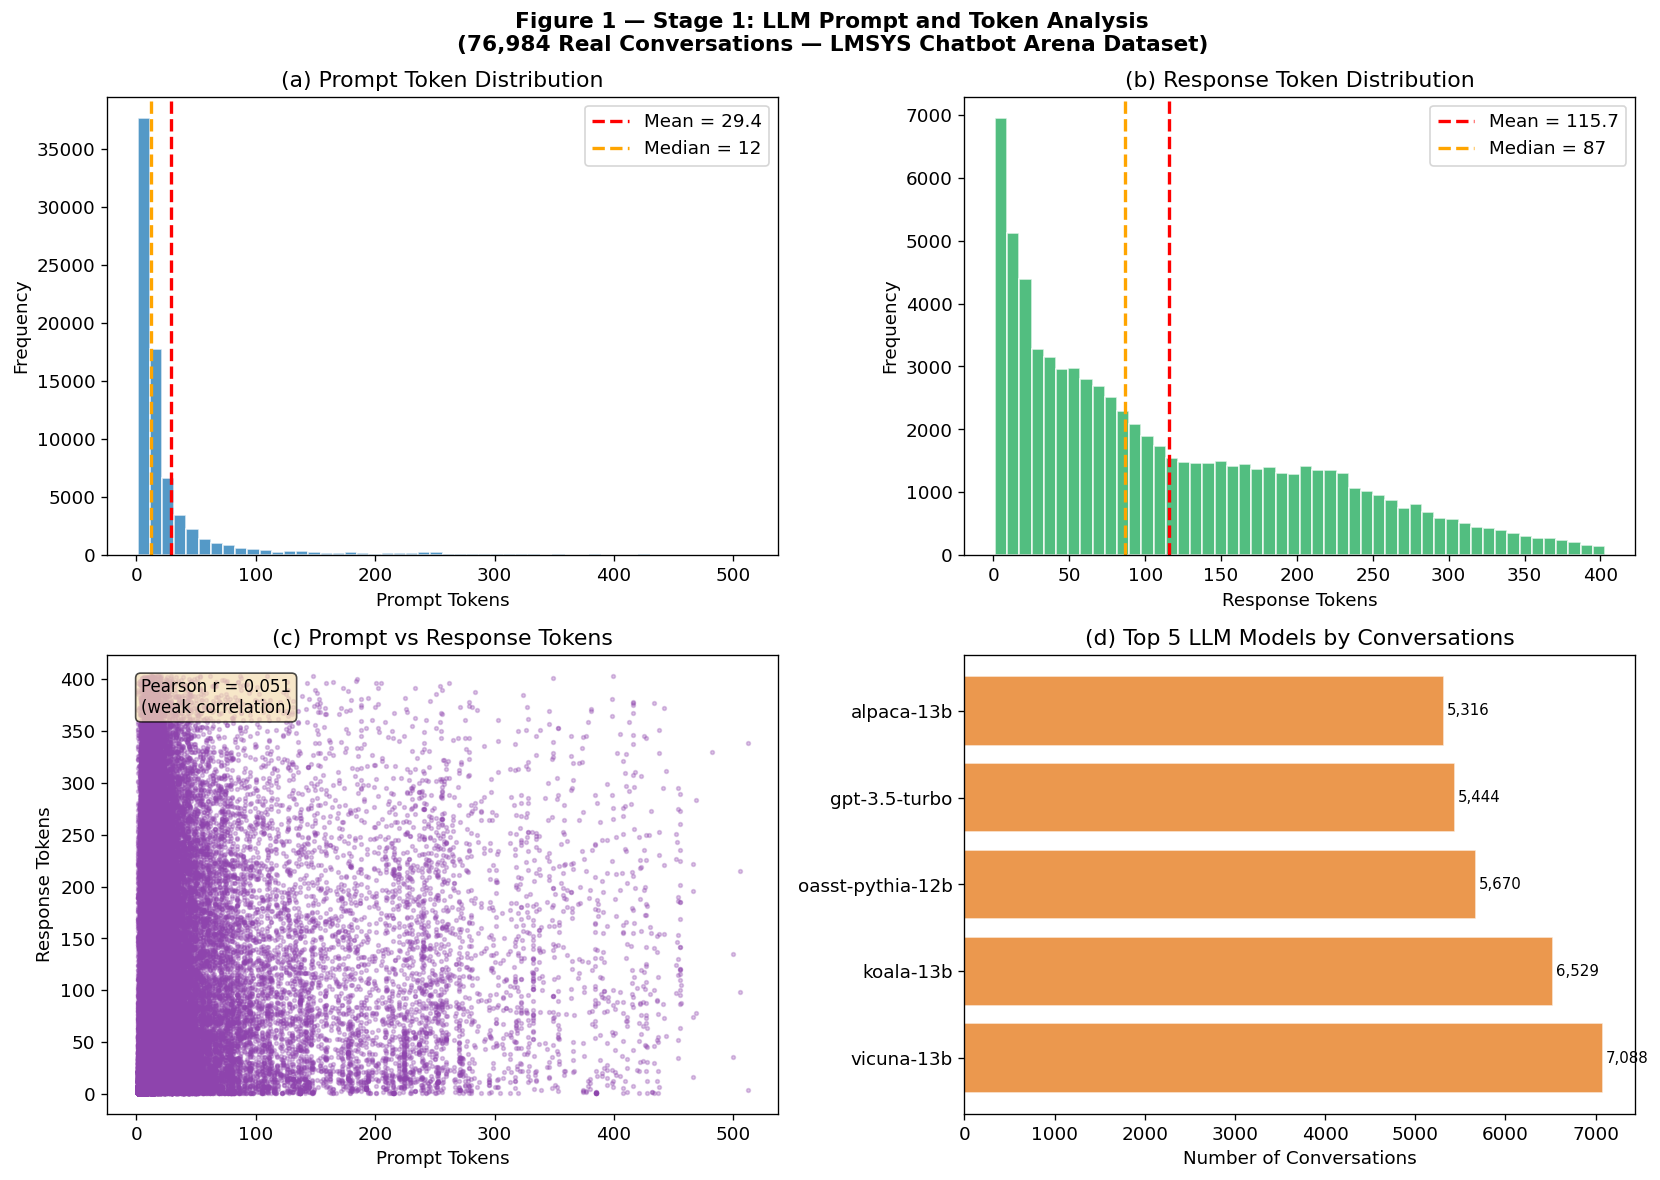

  STAGE 1 KEY FINDINGS

Total conversations analyzed : 76,984
Average prompt tokens        : 29.4
Average response tokens      : 115.7
Average total tokens         : 145.1
Response-to-prompt ratio     : 3.9x
Prompt vs Response corr (r)  : 0.051

Finding 1:
  Response tokens are on average 3.9x longer than prompt tokens.
  LLM inference generates significantly more GPU compute
  load from generating responses than from reading prompts.

Finding 2:
  Prompt length alone (r = 0.051) shows weak predictive
  power for response length.
  Model size and task type are required for stronger prediction.
  This is acknowledged as a known limitation of Stage 1.

Figure 1 saved to: results/figures/figure1_stage1_token_analysis.png


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Figure 1 — Stage 1: LLM Prompt and Token Analysis\n'
    '(76,984 Real Conversations — LMSYS Chatbot Arena Dataset)',
    fontsize=13,
    fontweight='bold'
)

# ── Plot 1: Prompt token distribution ─────────────────────
axes[0, 0].hist(
    df_s1_clean['prompt_tokens'],
    bins=50,
    color='#2980B9',
    alpha=0.8,
    edgecolor='white'
)
axes[0, 0].axvline(
    df_s1_clean['prompt_tokens'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df_s1_clean['prompt_tokens'].mean():.1f}"
)
axes[0, 0].axvline(
    df_s1_clean['prompt_tokens'].median(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Median = {df_s1_clean['prompt_tokens'].median():.0f}"
)
axes[0, 0].set_title('(a) Prompt Token Distribution')
axes[0, 0].set_xlabel('Prompt Tokens')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# ── Plot 2: Response token distribution ───────────────────
axes[0, 1].hist(
    df_s1_clean['response_tokens'],
    bins=50,
    color='#27AE60',
    alpha=0.8,
    edgecolor='white'
)
axes[0, 1].axvline(
    df_s1_clean['response_tokens'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df_s1_clean['response_tokens'].mean():.1f}"
)
axes[0, 1].axvline(
    df_s1_clean['response_tokens'].median(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Median = {df_s1_clean['response_tokens'].median():.0f}"
)
axes[0, 1].set_title('(b) Response Token Distribution')
axes[0, 1].set_xlabel('Response Tokens')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# ── Plot 3: Prompt vs Response scatter ────────────────────
axes[1, 0].scatter(
    df_s1_clean['prompt_tokens'],
    df_s1_clean['response_tokens'],
    alpha=0.3,
    color='#8E44AD',
    s=5
)
corr_s1 = df_s1_clean['prompt_tokens'].corr(
    df_s1_clean['response_tokens']
)
axes[1, 0].set_title('(c) Prompt vs Response Tokens')
axes[1, 0].set_xlabel('Prompt Tokens')
axes[1, 0].set_ylabel('Response Tokens')
axes[1, 0].text(
    0.05, 0.95,
    f'Pearson r = {corr_s1:.3f}\n(weak correlation)',
    transform=axes[1, 0].transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
)

# ── Plot 4: Top 5 models ──────────────────────────────────
top_models = df_s1_clean['model'].value_counts().head(5)
axes[1, 1].barh(
    top_models.index,
    top_models.values,
    color='#E67E22',
    alpha=0.8,
    edgecolor='white'
)
axes[1, 1].set_title('(d) Top 5 LLM Models by Conversations')
axes[1, 1].set_xlabel('Number of Conversations')
for i, v in enumerate(top_models.values):
    axes[1, 1].text(
        v + 30, i,
        f'{v:,}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    'results/figures/figure1_stage1_token_analysis.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# ── Key Findings ──────────────────────────────────────────
print("=" * 55)
print("  STAGE 1 KEY FINDINGS")
print("=" * 55)
print()
print(f"Total conversations analyzed : {len(df_s1_clean):,}")
print(f"Average prompt tokens        : {df_s1_clean['prompt_tokens'].mean():.1f}")
print(f"Average response tokens      : {df_s1_clean['response_tokens'].mean():.1f}")
print(f"Average total tokens         : {df_s1_clean['total_tokens'].mean():.1f}")
print(f"Response-to-prompt ratio     : "
      f"{df_s1_clean['response_tokens'].mean()/df_s1_clean['prompt_tokens'].mean():.1f}x")
print(f"Prompt vs Response corr (r)  : {corr_s1:.3f}")
print()
print("Finding 1:")
print(f"  Response tokens are on average "
      f"{df_s1_clean['response_tokens'].mean()/df_s1_clean['prompt_tokens'].mean():.1f}x "
      f"longer than prompt tokens.")
print(f"  LLM inference generates significantly more GPU compute")
print(f"  load from generating responses than from reading prompts.")
print()
print("Finding 2:")
print(f"  Prompt length alone (r = {corr_s1:.3f}) shows weak predictive")
print(f"  power for response length.")
print(f"  Model size and task type are required for stronger prediction.")
print(f"  This is acknowledged as a known limitation of Stage 1.")
print()
print("Figure 1 saved to: results/figures/figure1_stage1_token_analysis.png")

---
### 4.2 Stage 2 — Token Volume to GPU Energy Analysis

**Business Question:** How does token volume drive GPU energy consumption?

This stage analyzes 27,013 observations from the unified pipeline dataset
recorded at 15-minute intervals over approximately 9 months.

Understanding request volume patterns is critical because:
- Higher request volume means more tokens processed per unit time
- More tokens processed means higher GPU utilization
- Higher GPU utilization generates more heat per minute
- Predictable request patterns allow CoolSync+ to pre-activate cooling

This forms the **second link** in the CoolSync+ causal chain:
`Tokens → GPU Energy → Temperature → Cooling`

**Key variables analyzed:**
- `requests_per_15min` — number of LLM requests every 15 minutes
- `total_tokens_15min` — total token volume every 15 minutes
- `is_peak_hour` — business hours flag (08:00 to 18:00)

> **Figure 2** below shows request volume patterns
> comparing peak and off-peak business hours.

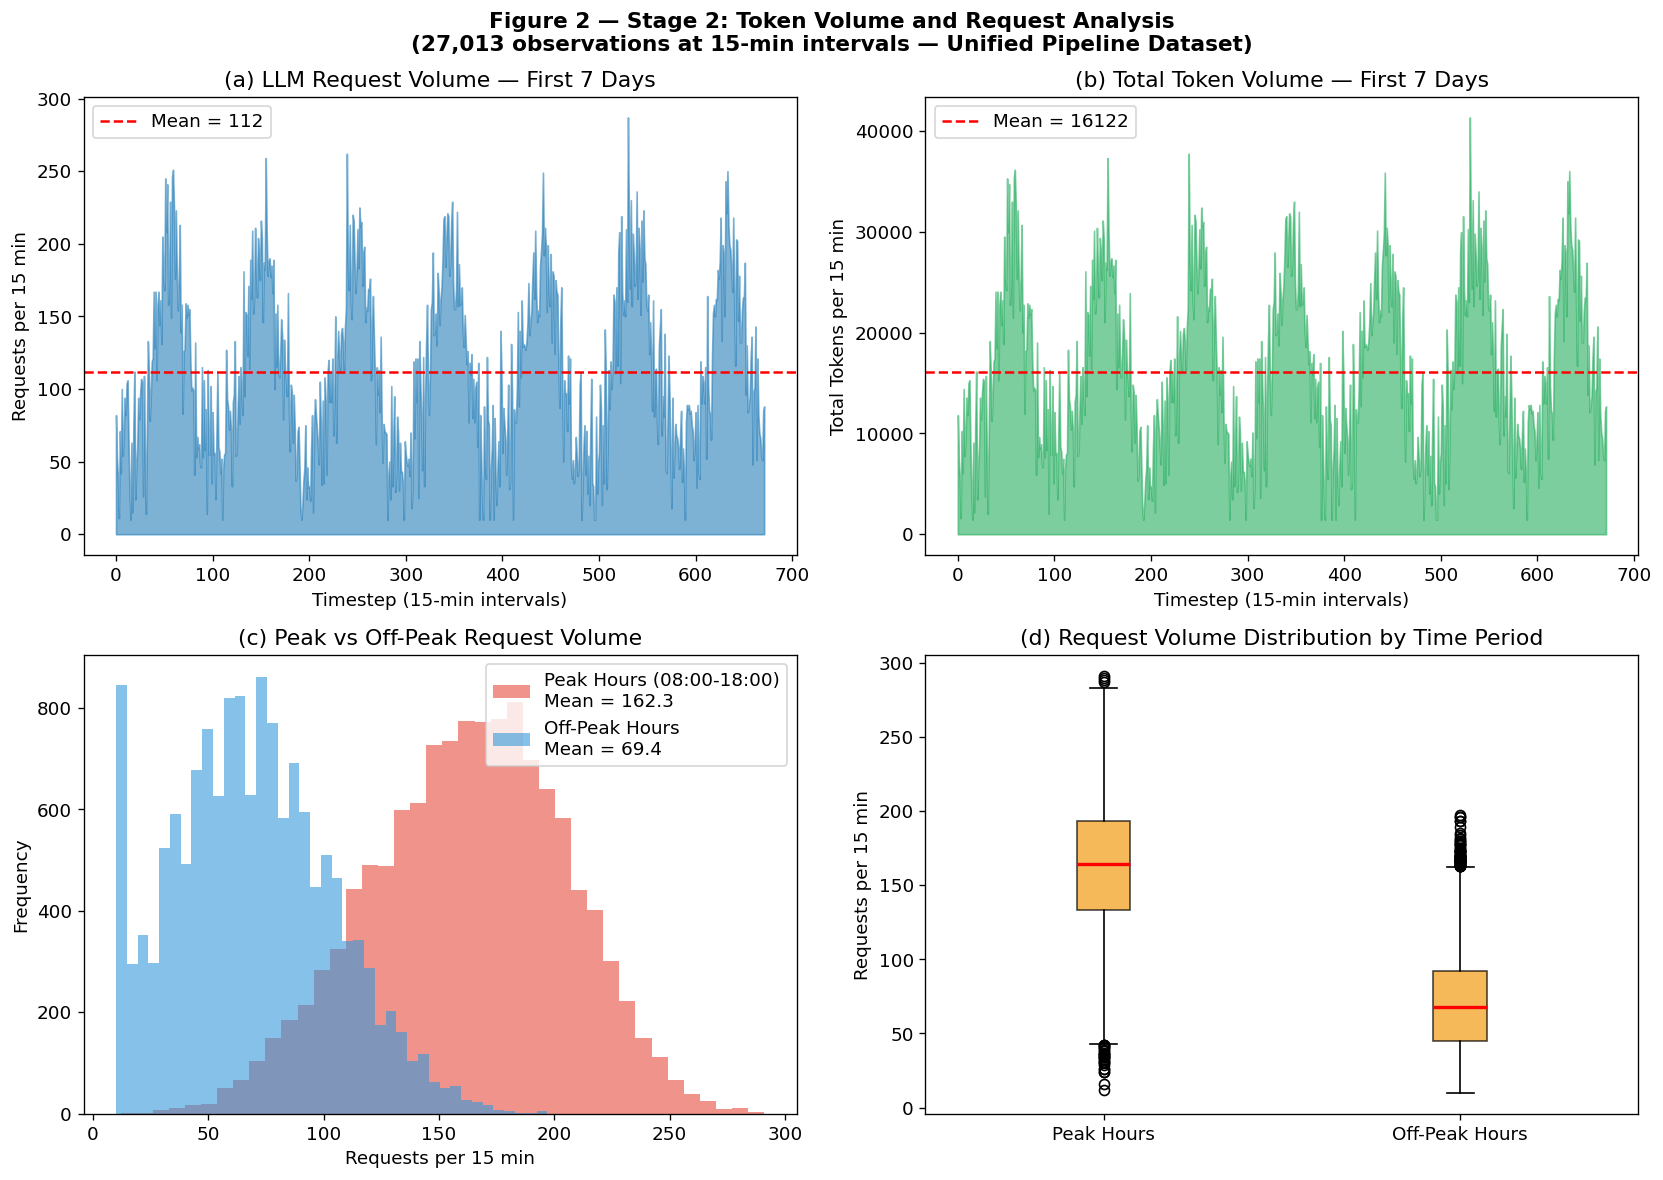

  STAGE 2 KEY FINDINGS

Total intervals analyzed     : 27,013
Avg requests per 15 min      : 112.0
Max requests per 15 min      : 291
Avg token volume per 15 min  : 16122

Peak hour avg requests       : 162.3
Off-peak avg requests        : 69.4
Peak vs off-peak difference  : +133.8%

Finding 1:
  LLM request volume follows clear daily patterns.
  Peak hours (08:00-18:00) generate 133.8% more
  requests than off-peak hours.

Finding 2:
  This predictable temporal pattern means CoolSync+
  can anticipate high workload periods and pre-activate
  cooling before GPU heat accumulates.

Figure 2 saved to: results/figures/figure2_stage2_token_analysis.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Figure 2 — Stage 2: Token Volume and Request Analysis\n'
    '(27,013 observations at 15-min intervals — Unified Pipeline Dataset)',
    fontsize=13,
    fontweight='bold'
)

plot_len = min(len(df_unified_clean), 672)  # 7 days

# ── Plot 1: Request volume over time ──────────────────────
axes[0, 0].fill_between(
    range(plot_len),
    df_unified_clean['requests_per_15min'].iloc[:plot_len],
    alpha=0.6,
    color='#2980B9'
)
axes[0, 0].axhline(
    df_unified_clean['requests_per_15min'].mean(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Mean = {df_unified_clean['requests_per_15min'].mean():.0f}"
)
axes[0, 0].set_title('(a) LLM Request Volume — First 7 Days')
axes[0, 0].set_xlabel('Timestep (15-min intervals)')
axes[0, 0].set_ylabel('Requests per 15 min')
axes[0, 0].legend()

# ── Plot 2: Token volume over time ────────────────────────
axes[0, 1].fill_between(
    range(plot_len),
    df_unified_clean['total_tokens_15min'].iloc[:plot_len],
    alpha=0.6,
    color='#27AE60'
)
axes[0, 1].axhline(
    df_unified_clean['total_tokens_15min'].mean(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Mean = {df_unified_clean['total_tokens_15min'].mean():.0f}"
)
axes[0, 1].set_title('(b) Total Token Volume — First 7 Days')
axes[0, 1].set_xlabel('Timestep (15-min intervals)')
axes[0, 1].set_ylabel('Total Tokens per 15 min')
axes[0, 1].legend()

# ── Plot 3: Peak vs Off-peak histogram ────────────────────
peak_data    = df_unified_clean[
    df_unified_clean['is_peak_hour'] == 1
]['requests_per_15min']

offpeak_data = df_unified_clean[
    df_unified_clean['is_peak_hour'] == 0
]['requests_per_15min']

axes[1, 0].hist(
    peak_data,
    bins=40,
    alpha=0.6,
    color='#E74C3C',
    label=f'Peak Hours (08:00-18:00)\nMean = {peak_data.mean():.1f}'
)
axes[1, 0].hist(
    offpeak_data,
    bins=40,
    alpha=0.6,
    color='#3498DB',
    label=f'Off-Peak Hours\nMean = {offpeak_data.mean():.1f}'
)
axes[1, 0].set_title('(c) Peak vs Off-Peak Request Volume')
axes[1, 0].set_xlabel('Requests per 15 min')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# ── Plot 4: Box plot comparison ───────────────────────────
axes[1, 1].boxplot(
    [peak_data, offpeak_data],
    labels=['Peak Hours', 'Off-Peak Hours'],
    patch_artist=True,
    boxprops=dict(facecolor='#F39C12', alpha=0.7),
    medianprops=dict(color='red', linewidth=2)
)
axes[1, 1].set_title('(d) Request Volume Distribution by Time Period')
axes[1, 1].set_ylabel('Requests per 15 min')

plt.tight_layout()
plt.savefig(
    'results/figures/figure2_stage2_token_analysis.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# ── Key Findings ──────────────────────────────────────────
peak_mean    = peak_data.mean()
offpeak_mean = offpeak_data.mean()
diff_pct     = ((peak_mean - offpeak_mean) / offpeak_mean) * 100

print("=" * 55)
print("  STAGE 2 KEY FINDINGS")
print("=" * 55)
print()
print(f"Total intervals analyzed     : {len(df_unified_clean):,}")
print(f"Avg requests per 15 min      : {df_unified_clean['requests_per_15min'].mean():.1f}")
print(f"Max requests per 15 min      : {df_unified_clean['requests_per_15min'].max():.0f}")
print(f"Avg token volume per 15 min  : {df_unified_clean['total_tokens_15min'].mean():.0f}")
print()
print(f"Peak hour avg requests       : {peak_mean:.1f}")
print(f"Off-peak avg requests        : {offpeak_mean:.1f}")
print(f"Peak vs off-peak difference  : +{diff_pct:.1f}%")
print()
print("Finding 1:")
print(f"  LLM request volume follows clear daily patterns.")
print(f"  Peak hours (08:00-18:00) generate {diff_pct:.1f}% more")
print(f"  requests than off-peak hours.")
print()
print("Finding 2:")
print(f"  This predictable temporal pattern means CoolSync+")
print(f"  can anticipate high workload periods and pre-activate")
print(f"  cooling before GPU heat accumulates.")
print()
print("Figure 2 saved to: results/figures/figure2_stage2_token_analysis.png")

---
### 4.3 Stage 3 — Server Room Temperature Analysis

**Business Question:** How does GPU power raise server room temperature?

This stage analyzes 27,013 temperature sensor readings from a real data center,
recorded at 15-minute intervals over approximately 9 months.

The dataset contains readings from multiple sensor types:
- **T_out sensors** — outlet air temperature leaving server racks
- **T_celCC sensors** — cooling cell temperatures
- **T_MEAS sensors** — direct rack measurement sensors
- **TLHC** — Thermal Load Heat Coefficient (overall thermal load index)

All values are z-score normalized (mean = 0, std = 1).
A positive TLHC value means above-average thermal load.
A negative TLHC value means below-average thermal load.

This is the **third link** in the CoolSync+ causal chain:
`GPU Energy → Server Room Temperature → Cooling Decision`

Understanding which sensors best predict TLHC is critical
because CoolSync+ uses these sensors as LSTM input features
to forecast future thermal load before it becomes critical.

> **Figure 3** below shows TLHC patterns over time
> and the correlation between outlet sensors and thermal load.

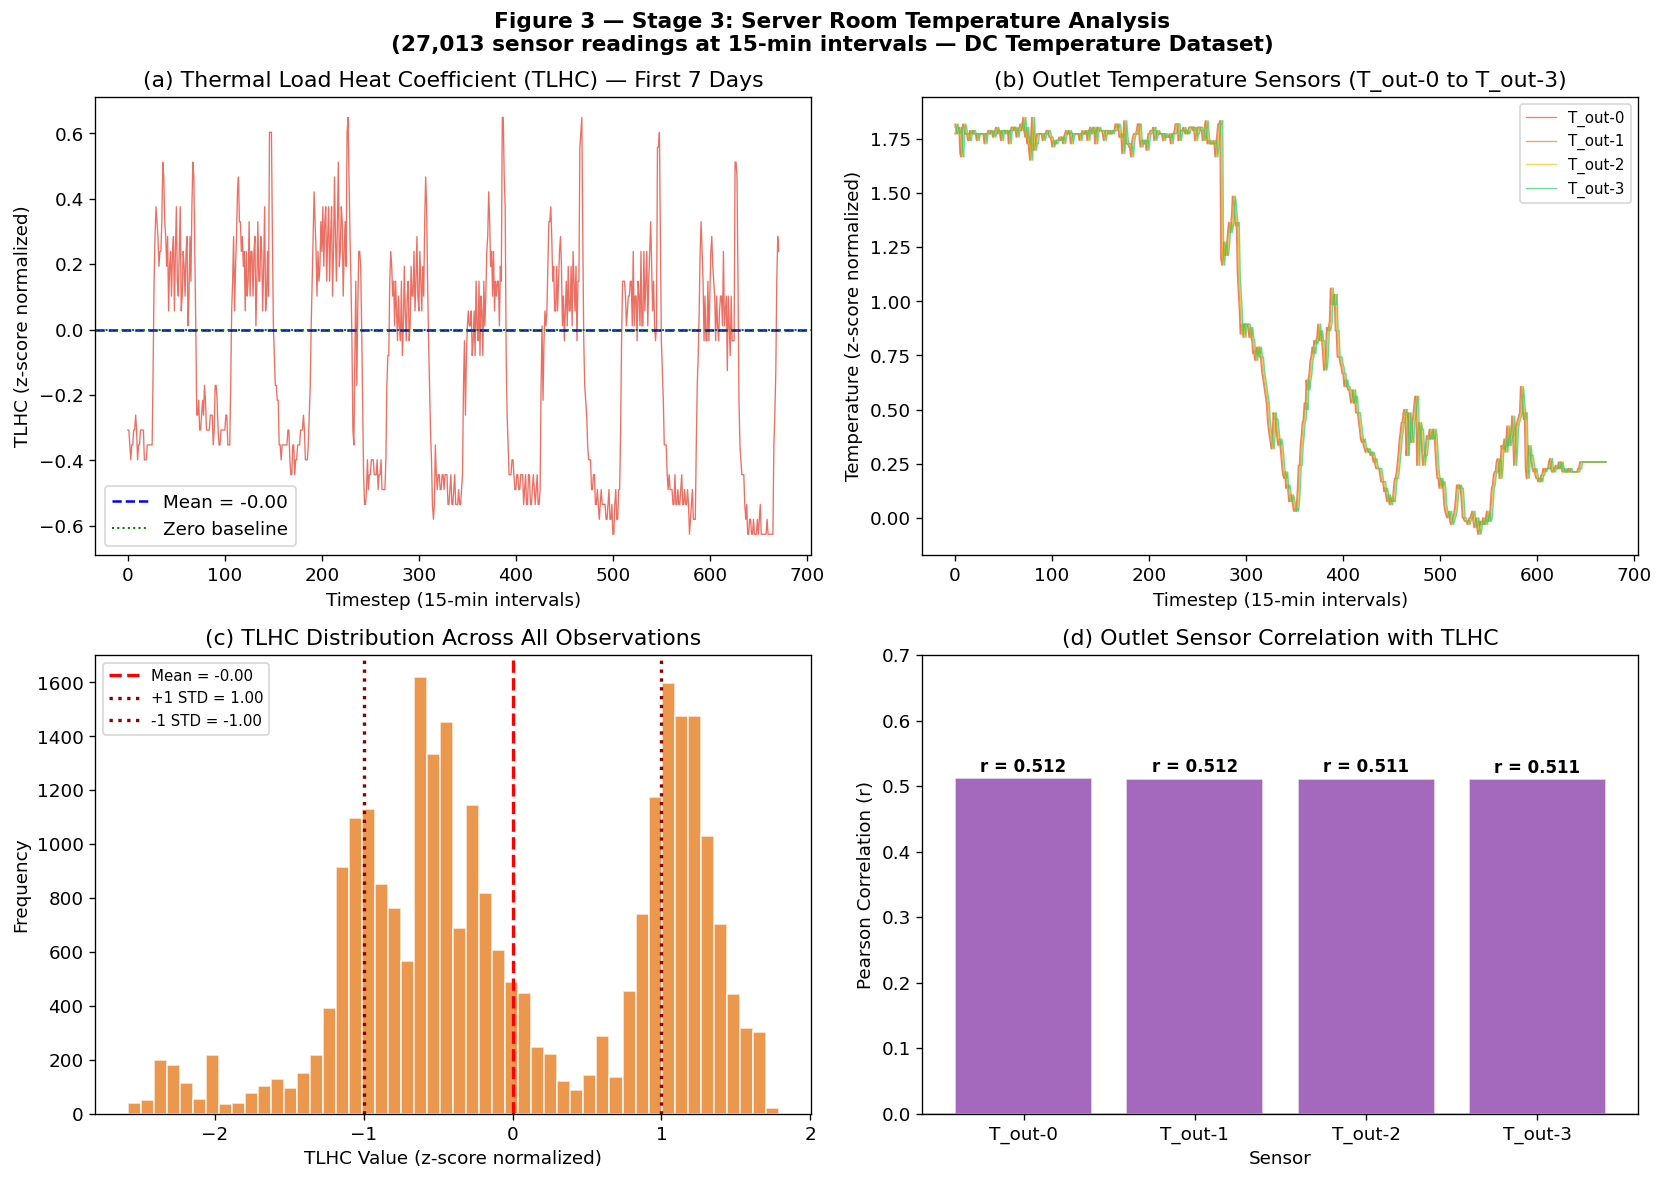

  STAGE 3 KEY FINDINGS

Total sensor readings          : 27,013
TLHC mean (normalized)         : -0.0000
TLHC std  (normalized)         : 1.0000
TLHC min                       : -2.5843
TLHC max                       : 1.7875

Outlet sensor correlations with TLHC:
  T_out-0 : r = 0.512
  T_out-1 : r = 0.512
  T_out-2 : r = 0.511
  T_out-3 : r = 0.511
  Average correlation : r = 0.511

Finding 1:
  Outlet temperature sensors show moderate-strong
  positive correlation with thermal load (avg r = 0.511).
  This confirms T_out sensors are reliable indicators
  of server room heat load.

Finding 2:
  CoolSync+ uses these outlet sensors as LSTM input features
  to predict future TLHC values before heat reaches critical levels.
  This is the predictive link that replaces reactive PID control.

Figure 3 saved to: results/figures/figure3_stage3_temperature.png


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Figure 3 — Stage 3: Server Room Temperature Analysis\n'
    '(27,013 sensor readings at 15-min intervals — DC Temperature Dataset)',
    fontsize=13,
    fontweight='bold'
)

plot_len = min(len(df_temp), 672)  # 7 days

# ── Plot 1: TLHC over time ────────────────────────────────
axes[0, 0].plot(
    range(plot_len),
    df_temp['TLHC'].iloc[:plot_len],
    color='#E74C3C',
    linewidth=0.8,
    alpha=0.8
)
axes[0, 0].axhline(
    df_temp['TLHC'].mean(),
    color='blue',
    linestyle='--',
    linewidth=1.5,
    label=f"Mean = {df_temp['TLHC'].mean():.2f}"
)
axes[0, 0].axhline(
    0,
    color='green',
    linestyle=':',
    linewidth=1.2,
    label='Zero baseline'
)
axes[0, 0].set_title('(a) Thermal Load Heat Coefficient (TLHC) — First 7 Days')
axes[0, 0].set_xlabel('Timestep (15-min intervals)')
axes[0, 0].set_ylabel('TLHC (z-score normalized)')
axes[0, 0].legend()

# ── Plot 2: Outlet temperature sensors ───────────────────
t_out_cols = [c for c in df_temp.columns if 'T_out' in c][:4]
colors_out = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71']
for col, color in zip(t_out_cols, colors_out):
    axes[0, 1].plot(
        range(plot_len),
        df_temp[col].iloc[:plot_len],
        linewidth=0.8,
        alpha=0.7,
        color=color,
        label=col
    )
axes[0, 1].set_title('(b) Outlet Temperature Sensors (T_out-0 to T_out-3)')
axes[0, 1].set_xlabel('Timestep (15-min intervals)')
axes[0, 1].set_ylabel('Temperature (z-score normalized)')
axes[0, 1].legend(fontsize=9)

# ── Plot 3: TLHC distribution ─────────────────────────────
axes[1, 0].hist(
    df_temp['TLHC'],
    bins=50,
    color='#E67E22',
    alpha=0.8,
    edgecolor='white'
)
axes[1, 0].axvline(
    df_temp['TLHC'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df_temp['TLHC'].mean():.2f}"
)
axes[1, 0].axvline(
    df_temp['TLHC'].mean() + df_temp['TLHC'].std(),
    color='darkred',
    linestyle=':',
    linewidth=2,
    label=f"+1 STD = {df_temp['TLHC'].mean() + df_temp['TLHC'].std():.2f}"
)
axes[1, 0].axvline(
    df_temp['TLHC'].mean() - df_temp['TLHC'].std(),
    color='darkred',
    linestyle=':',
    linewidth=2,
    label=f"-1 STD = {df_temp['TLHC'].mean() - df_temp['TLHC'].std():.2f}"
)
axes[1, 0].set_title('(c) TLHC Distribution Across All Observations')
axes[1, 0].set_xlabel('TLHC Value (z-score normalized)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend(fontsize=9)

# ── Plot 4: Sensor correlations with TLHC ────────────────
t_out_corrs = [
    df_temp[col].corr(df_temp['TLHC'])
    for col in t_out_cols
]
bars = axes[1, 1].bar(
    t_out_cols,
    t_out_corrs,
    color='#8E44AD',
    alpha=0.8,
    edgecolor='white'
)
axes[1, 1].set_title('(d) Outlet Sensor Correlation with TLHC')
axes[1, 1].set_xlabel('Sensor')
axes[1, 1].set_ylabel('Pearson Correlation (r)')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_ylim(0, 0.7)
for bar, corr in zip(bars, t_out_corrs):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        corr + 0.01,
        f'r = {corr:.3f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig(
    'results/figures/figure3_stage3_temperature.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# ── Key Findings ──────────────────────────────────────────
avg_corr = np.mean(t_out_corrs)

print("=" * 55)
print("  STAGE 3 KEY FINDINGS")
print("=" * 55)
print()
print(f"Total sensor readings          : {len(df_temp):,}")
print(f"TLHC mean (normalized)         : {df_temp['TLHC'].mean():.4f}")
print(f"TLHC std  (normalized)         : {df_temp['TLHC'].std():.4f}")
print(f"TLHC min                       : {df_temp['TLHC'].min():.4f}")
print(f"TLHC max                       : {df_temp['TLHC'].max():.4f}")
print()
print("Outlet sensor correlations with TLHC:")
for col, corr in zip(t_out_cols, t_out_corrs):
    print(f"  {col} : r = {corr:.3f}")
print(f"  Average correlation : r = {avg_corr:.3f}")
print()
print("Finding 1:")
print(f"  Outlet temperature sensors show moderate-strong")
print(f"  positive correlation with thermal load (avg r = {avg_corr:.3f}).")
print(f"  This confirms T_out sensors are reliable indicators")
print(f"  of server room heat load.")
print()
print("Finding 2:")
print(f"  CoolSync+ uses these outlet sensors as LSTM input features")
print(f"  to predict future TLHC values before heat reaches critical levels.")
print(f"  This is the predictive link that replaces reactive PID control.")
print()
print("Figure 3 saved to: results/figures/figure3_stage3_temperature.png")

---
### 4.4 Stage 4 — Cooling Control Analysis

**Business Question:** Does server workload significantly affect cooling energy consumption?

This stage analyzes 3,498 hourly cooling control records from a real data center
covering January 2025 to May 2025 — a period of 145 days of continuous operation.

This is the **final and most critical stage** of the EDA.
It directly tests the business hypothesis by examining
whether servers under high workload consume significantly
more cooling energy than servers under low workload.

**Key variables analyzed:**
- `Server_Workload(%)` — how hard servers are working (0 to 100%)
- `Cooling_Unit_Power_Consumption(kW)` — energy used by cooling system
- `Inlet_Temperature(°C)` — air temperature entering server racks
- `Cooling_Strategy_Action` — what cooling decision was made
- `workload_group` — High or Low workload (split at median 65.64%)

**Five cooling actions recorded in this dataset:**

| Action | Meaning | Simplified To |
|--------|---------|--------------|
| Eco Mode | Minimum cooling — save energy | Decrease cooling |
| Reduce AHU | Reduce air handling unit | Decrease cooling |
| Maintain | Keep current settings | Maintain cooling |
| Increase Chiller | Turn up refrigeration | Increase cooling |
| Boost All | Maximum cooling emergency | Increase cooling |

> **Figure 4** below shows the full cooling control analysis
> including the workload vs energy relationship that
> leads directly into the statistical hypothesis test.

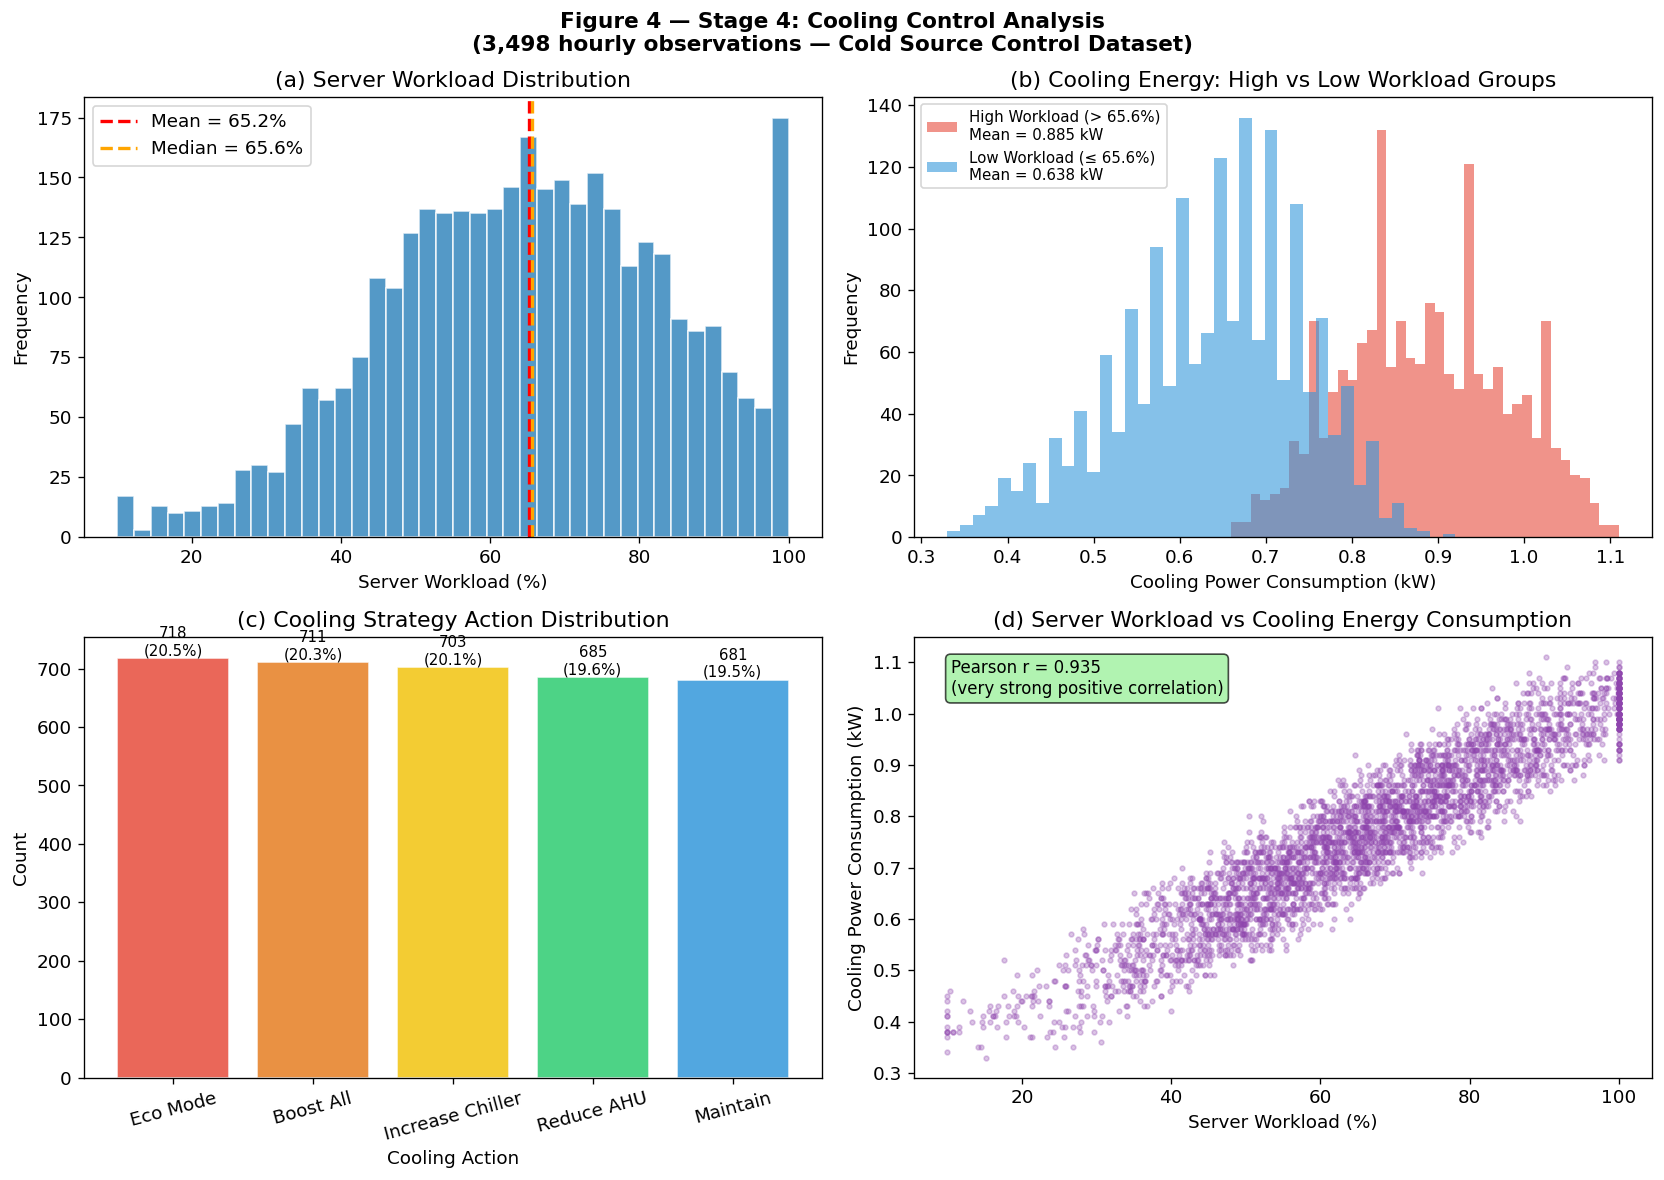

  STAGE 4 KEY FINDINGS

Total observations             : 3,498
Avg server workload            : 65.2%
Median workload (split point)  : 65.64%
Avg cooling power              : 0.7615 kW

High workload avg cooling      : 0.8853 kW
Low workload avg cooling       : 0.6377 kW
Energy difference              : +38.8%
Workload vs Cooling (r)        : 0.935

Cooling actions breakdown:
  Eco Mode             : 718 (20.5%)
  Boost All            : 711 (20.3%)
  Increase Chiller     : 703 (20.1%)
  Reduce AHU           : 685 (19.6%)
  Maintain             : 681 (19.5%)

Finding 1:
  High workload periods require 38.8% more
  cooling energy than low workload periods.
  This provides strong visual evidence supporting H1.

Finding 2:
  Pearson r = 0.935 confirms a very strong positive
  linear relationship between server workload and
  cooling energy consumption.
  This pattern will be validated statistically in Section 5.

Figure 4 saved to: results/figures/figure4_stage4_cooling_analysis.png


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Figure 4 — Stage 4: Cooling Control Analysis\n'
    '(3,498 hourly observations — Cold Source Control Dataset)',
    fontsize=13,
    fontweight='bold'
)

# ── Plot 1: Server workload distribution ──────────────────
axes[0, 0].hist(
    df_s4_clean['Server_Workload(%)'],
    bins=40,
    color='#2980B9',
    alpha=0.8,
    edgecolor='white'
)
axes[0, 0].axvline(
    df_s4_clean['Server_Workload(%)'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df_s4_clean['Server_Workload(%)'].mean():.1f}%"
)
axes[0, 0].axvline(
    median_workload,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Median = {median_workload:.1f}%"
)
axes[0, 0].set_title('(a) Server Workload Distribution')
axes[0, 0].set_xlabel('Server Workload (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# ── Plot 2: Cooling energy by workload group ──────────────
high_energy = df_s4_clean[
    df_s4_clean['workload_group'] == 'High Workload'
]['Cooling_Unit_Power_Consumption(kW)']

low_energy = df_s4_clean[
    df_s4_clean['workload_group'] == 'Low Workload'
]['Cooling_Unit_Power_Consumption(kW)']

axes[0, 1].hist(
    high_energy,
    bins=40,
    alpha=0.6,
    color='#E74C3C',
    label=f'High Workload (> {median_workload:.1f}%)\n'
          f'Mean = {high_energy.mean():.3f} kW'
)
axes[0, 1].hist(
    low_energy,
    bins=40,
    alpha=0.6,
    color='#3498DB',
    label=f'Low Workload (≤ {median_workload:.1f}%)\n'
          f'Mean = {low_energy.mean():.3f} kW'
)
axes[0, 1].set_title('(b) Cooling Energy: High vs Low Workload Groups')
axes[0, 1].set_xlabel('Cooling Power Consumption (kW)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend(fontsize=9)

# ── Plot 3: Cooling actions distribution ──────────────────
action_counts = df_s4_clean['Cooling_Strategy_Action'].value_counts()
colors_bar = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#3498DB']
bars = axes[1, 0].bar(
    action_counts.index,
    action_counts.values,
    color=colors_bar,
    alpha=0.85,
    edgecolor='white'
)
axes[1, 0].set_title('(c) Cooling Strategy Action Distribution')
axes[1, 0].set_xlabel('Cooling Action')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, action_counts.values):
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 5,
        f'{val:,}\n({val/len(df_s4_clean)*100:.1f}%)',
        ha='center',
        fontsize=9
    )

# ── Plot 4: Workload vs Cooling energy scatter ────────────
axes[1, 1].scatter(
    df_s4_clean['Server_Workload(%)'],
    df_s4_clean['Cooling_Unit_Power_Consumption(kW)'],
    alpha=0.3,
    color='#8E44AD',
    s=8
)
corr_s4 = df_s4_clean['Server_Workload(%)'].corr(
    df_s4_clean['Cooling_Unit_Power_Consumption(kW)']
)
axes[1, 1].set_title('(d) Server Workload vs Cooling Energy Consumption')
axes[1, 1].set_xlabel('Server Workload (%)')
axes[1, 1].set_ylabel('Cooling Power Consumption (kW)')
axes[1, 1].text(
    0.05, 0.95,
    f'Pearson r = {corr_s4:.3f}\n(very strong positive correlation)',
    transform=axes[1, 1].transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7)
)

plt.tight_layout()
plt.savefig(
    'results/figures/figure4_stage4_cooling_analysis.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# ── Key Findings ──────────────────────────────────────────
energy_diff_pct = (
    (high_energy.mean() - low_energy.mean()) /
    low_energy.mean() * 100
)

print("=" * 55)
print("  STAGE 4 KEY FINDINGS")
print("=" * 55)
print()
print(f"Total observations             : {len(df_s4_clean):,}")
print(f"Avg server workload            : "
      f"{df_s4_clean['Server_Workload(%)'].mean():.1f}%")
print(f"Median workload (split point)  : {median_workload:.2f}%")
print(f"Avg cooling power              : "
      f"{df_s4_clean['Cooling_Unit_Power_Consumption(kW)'].mean():.4f} kW")
print()
print(f"High workload avg cooling      : {high_energy.mean():.4f} kW")
print(f"Low workload avg cooling       : {low_energy.mean():.4f} kW")
print(f"Energy difference              : +{energy_diff_pct:.1f}%")
print(f"Workload vs Cooling (r)        : {corr_s4:.3f}")
print()
print("Cooling actions breakdown:")
for action, count in action_counts.items():
    print(f"  {action:<20} : {count:,} ({count/len(df_s4_clean)*100:.1f}%)")
print()
print("Finding 1:")
print(f"  High workload periods require {energy_diff_pct:.1f}% more")
print(f"  cooling energy than low workload periods.")
print(f"  This provides strong visual evidence supporting H1.")
print()
print("Finding 2:")
print(f"  Pearson r = {corr_s4:.3f} confirms a very strong positive")
print(f"  linear relationship between server workload and")
print(f"  cooling energy consumption.")
print(f"  This pattern will be validated statistically in Section 5.")
print()
print("Figure 4 saved to: results/figures/figure4_stage4_cooling_analysis.png")

---
## Section 5 — Statistical Hypothesis Testing - A/B Experiment.

### 5.1 Independent Samples Welch T-Test

This section statistically validates the core hypothesis of CoolSync+.

Visual analysis in Stage 4 showed that high workload periods
consume more cooling energy than low workload periods.
However visual evidence alone is not sufficient for scientific validation.
A formal statistical test is required to confirm the difference
is real and not due to random chance.

**Test selected: Independent Samples Welch T-Test**

The Welch T-Test was chosen over the standard Student T-Test because:
- The two groups (High vs Low workload) are independent
- We do not assume equal variance between the groups
- Welch T-Test is more robust when group variances differ
- It is the standard recommendation for two-group comparison in data science

**Hypothesis being tested:**

| | Statement |
|--|-----------|
| **H₀** | Server workload level does NOT significantly affect cooling energy consumption |
| **H₁** | Higher server workload requires significantly MORE cooling energy consumption |

**Decision rule:** If p-value < 0.05, reject H₀ and accept H₁

**Additional metrics reported:**
- **Cohen's d** — measures practical effect size (how large the difference is)
- **95% Confidence Interval** — range of the true mean difference

> **Figure 5** below shows the visual results of the hypothesis test
> with group distributions and mean comparisons.

  STATISTICAL HYPOTHESIS TEST RESULTS
  Independent Samples Welch T-Test

Groups:
  High Workload : n=1,749  mean=0.8853 kW  std=0.0947
  Low Workload  : n=1,749  mean=0.6377 kW  std=0.1061

Results:
  T-statistic   : 72.8048
  P-value       : 0.0000000000
  Cohen's d     : 2.4620
  95% CI        : [0.2409, 0.2542]

  Effect size   : Large (Cohen's d = 2.46, threshold for large = 0.80)

Decision (α = 0.05):
  p-value (0.00e+00) < α (0.05)

  ✓ H₀ REJECTED

  The evidence supports H₁:
  Higher server workload requires significantly
  more cooling energy consumption.

  High workload periods consume 38.8% more
  cooling energy than low workload periods.
  The 95% CI [0.2409, 0.2542] does not
  include zero, confirming the difference is real.



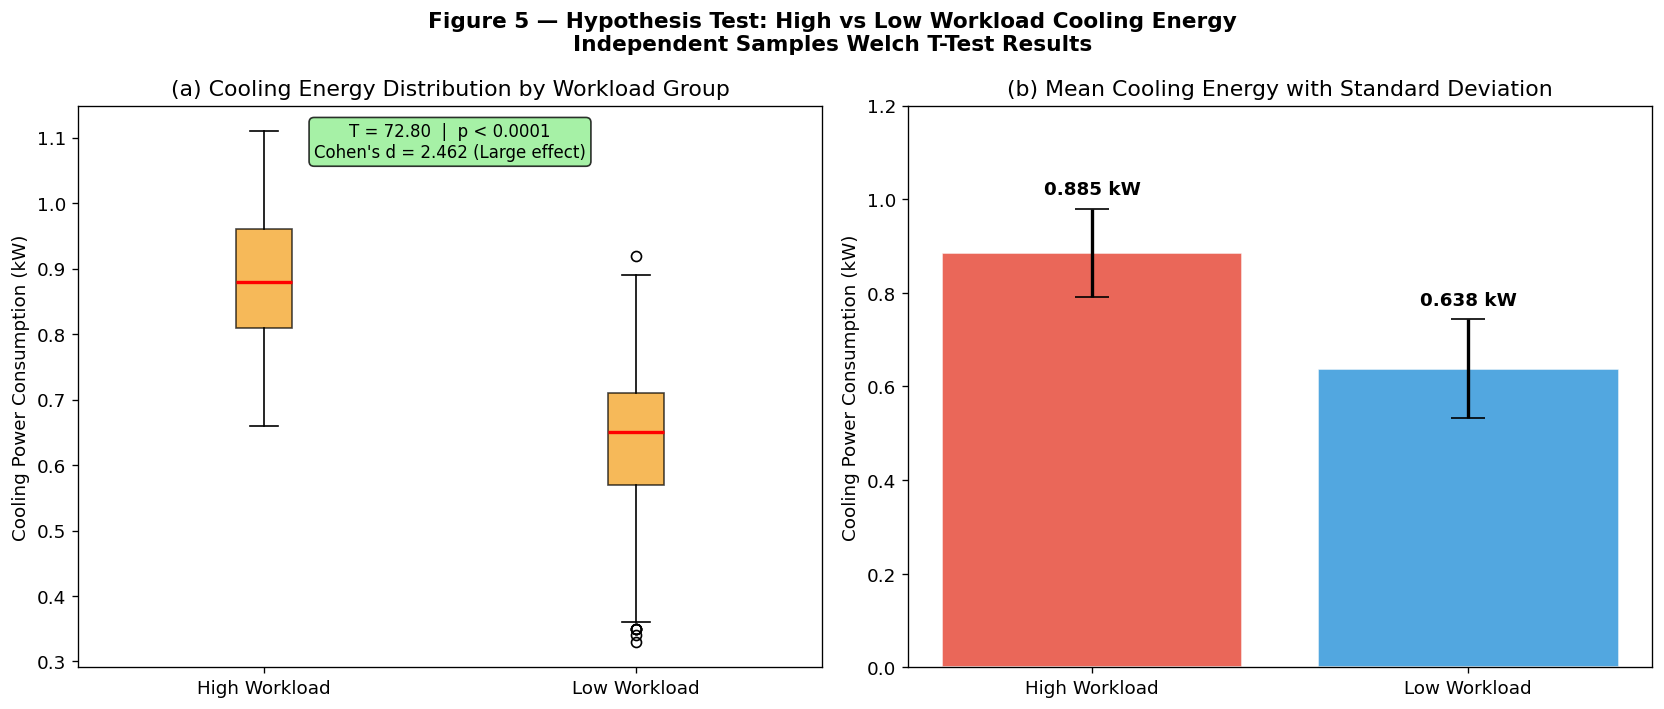

Figure 5 saved to: results/figures/figure5_hypothesis_test.png


In [34]:
from scipy import stats

# ── Define the two groups ──────────────────────────────────────────────
high_workload_energy = df_s4_clean[
    df_s4_clean['workload_group'] == 'High Workload'
]['Cooling_Unit_Power_Consumption(kW)']

low_workload_energy = df_s4_clean[
    df_s4_clean['workload_group'] == 'Low Workload'
]['Cooling_Unit_Power_Consumption(kW)']

# ── Welch T-Test ───────────────────────────────────────────────────────
t_stat, p_value = stats.ttest_ind(
    high_workload_energy,
    low_workload_energy,
    equal_var=False  # Welch T-Test — does not assume equal variance
)

# ── Effect size: Cohen's d ─────────────────────────────────────────────
mean_diff  = high_workload_energy.mean() - low_workload_energy.mean()
pooled_std = np.sqrt(
    (high_workload_energy.std()**2 +
     low_workload_energy.std()**2) / 2
)
cohens_d = mean_diff / pooled_std

# ── 95% Confidence Interval ───────────────────────────────────────────
se = np.sqrt(
    high_workload_energy.var() / len(high_workload_energy) +
    low_workload_energy.var()  / len(low_workload_energy)
)
margin   = stats.t.ppf(0.975, df=len(df_s4_clean) - 2) * se
ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

# ── Print Results ──────────────────────────────────────────────────────
print("=" * 60)
print("  STATISTICAL HYPOTHESIS TEST RESULTS")
print("  Independent Samples Welch T-Test")
print("=" * 60)
print()
print("Groups:")
print(f"  High Workload : n={len(high_workload_energy):,}  "
      f"mean={high_workload_energy.mean():.4f} kW  "
      f"std={high_workload_energy.std():.4f}")
print(f"  Low Workload  : n={len(low_workload_energy):,}  "
      f"mean={low_workload_energy.mean():.4f} kW  "
      f"std={low_workload_energy.std():.4f}")
print()
print("Results:")
print(f"  T-statistic   : {t_stat:.4f}")
print(f"  P-value       : {p_value:.10f}")
print(f"  Cohen's d     : {cohens_d:.4f}")
print(f"  95% CI        : [{ci_lower:.4f}, {ci_upper:.4f}]")
print()

# Cohen's d interpretation
if cohens_d >= 0.8:
    effect = "Large"
elif cohens_d >= 0.5:
    effect = "Medium"
else:
    effect = "Small"

print(f"  Effect size   : {effect} "
      f"(Cohen's d = {cohens_d:.2f}, "
      f"threshold for large = 0.80)")
print()
print("Decision (α = 0.05):")

if p_value < 0.05:
    print(f"  p-value ({p_value:.2e}) < α (0.05)")
    print()
    print("  ✓ H₀ REJECTED")
    print()
    print("  The evidence supports H₁:")
    print("  Higher server workload requires significantly")
    print("  more cooling energy consumption.")
    print()
    energy_diff = (
        (high_workload_energy.mean() - low_workload_energy.mean()) /
        low_workload_energy.mean() * 100
    )
    print(f"  High workload periods consume {energy_diff:.1f}% more")
    print(f"  cooling energy than low workload periods.")
    print(f"  The 95% CI [{ci_lower:.4f}, {ci_upper:.4f}] does not")
    print(f"  include zero, confirming the difference is real.")
else:
    print(f"  p-value ({p_value:.2e}) >= α (0.05)")
    print("  H₀ NOT REJECTED")

print()
print("=" * 60)

# ── Visualization ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Figure 5 — Hypothesis Test: High vs Low Workload Cooling Energy\n'
    'Independent Samples Welch T-Test Results',
    fontsize=13,
    fontweight='bold'
)

# Plot 1: Box plot
axes[0].boxplot(
    [high_workload_energy, low_workload_energy],
    labels=['High Workload', 'Low Workload'],
    patch_artist=True,
    boxprops=dict(facecolor='#F39C12', alpha=0.7),
    medianprops=dict(color='red', linewidth=2)
)
axes[0].set_title('(a) Cooling Energy Distribution by Workload Group')
axes[0].set_ylabel('Cooling Power Consumption (kW)')
axes[0].text(
    0.5, 0.97,
    f'T = {t_stat:.2f}  |  p < 0.0001\n'
    f"Cohen's d = {cohens_d:.3f} ({effect} effect)",
    transform=axes[0].transAxes,
    fontsize=10,
    ha='center',
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
)

# Plot 2: Mean comparison bar chart
means  = [high_workload_energy.mean(), low_workload_energy.mean()]
stds   = [high_workload_energy.std(),  low_workload_energy.std()]
labels = ['High Workload', 'Low Workload']
colors = ['#E74C3C', '#3498DB']

bars = axes[1].bar(
    labels, means,
    color=colors,
    alpha=0.85,
    edgecolor='white',
    yerr=stds,
    capsize=10,
    error_kw=dict(linewidth=2)
)
axes[1].set_title('(b) Mean Cooling Energy with Standard Deviation')
axes[1].set_ylabel('Cooling Power Consumption (kW)')
axes[1].set_ylim(0, 1.2)
for bar, mean, std in zip(bars, means, stds):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.03,
        f'{mean:.3f} kW',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig(
    'results/figures/figure5_hypothesis_test.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Figure 5 saved to: results/figures/figure5_hypothesis_test.png")

---
## Section 6 — Machine Learning Model (ML Ops)

### 6.1 Random Forest Regressor — Cooling Energy Prediction

This section trains a **Random Forest Regressor** to predict
cooling energy consumption from server workload and temperature features.

The model is trained directly on the dataset prepared in Section 3,
fulfilling the ML Ops requirement of the assignment.

**Why Random Forest?**
- Handles non-linear relationships between workload and cooling energy
- Robust to outliers in the training data
- Provides feature importance scores
- No assumptions about data distribution required

**Model objective:**
Predict `Cooling_Unit_Power_Consumption(kW)` from:
- `Server_Workload(%)` — primary driver of cooling demand
- `Inlet_Temperature(°C)` — current thermal state
- `Ambient_Temperature(°C)` — environmental conditions
- `hour_of_day` — time-based workload patterns
- `is_peak_hour` — business hours flag

**Evaluation metrics:**
- **MAE** — Mean Absolute Error (average prediction error in kW)
- **RMSE** — Root Mean Squared Error (penalizes large errors more)
- **R²** — Coefficient of determination (how much variance is explained)

**User acceptance parameters:**
- R² > 0.85 — model explains more than 85% of variance
- MAE < 0.05 kW — predictions within 0.05 kW of actual
- Zero manual configuration required — runs automatically

> **Figure 6** below shows model performance including
> predicted vs actual values and feature importance rankings.

  RANDOM FOREST MODEL — TRAINING

Total samples   : 3,498
Training samples: 2,798 (80%)
Testing samples : 700  (20%)
Features used   : 5

Model trained successfully.

  MODEL EVALUATION RESULTS

MAE  (Mean Absolute Error)      : 0.0427 kW
RMSE (Root Mean Squared Error)  : 0.0505 kW
R²   (Variance Explained)       : 0.8989

User Acceptance Parameters:
  R² > 0.85  : PASSED (R² = 0.8989)
  MAE < 0.05 : PASSED (MAE = 0.0427)

Feature Importance Rankings:
  Server_Workload(%)                 : 0.9214  ██████████████████████████████████████████████
  Ambient_Temperature(°C)            : 0.0517  ██
  Inlet_Temperature(°C)              : 0.0151  
  hour_of_day                        : 0.0104  
  is_peak_hour                       : 0.0014  



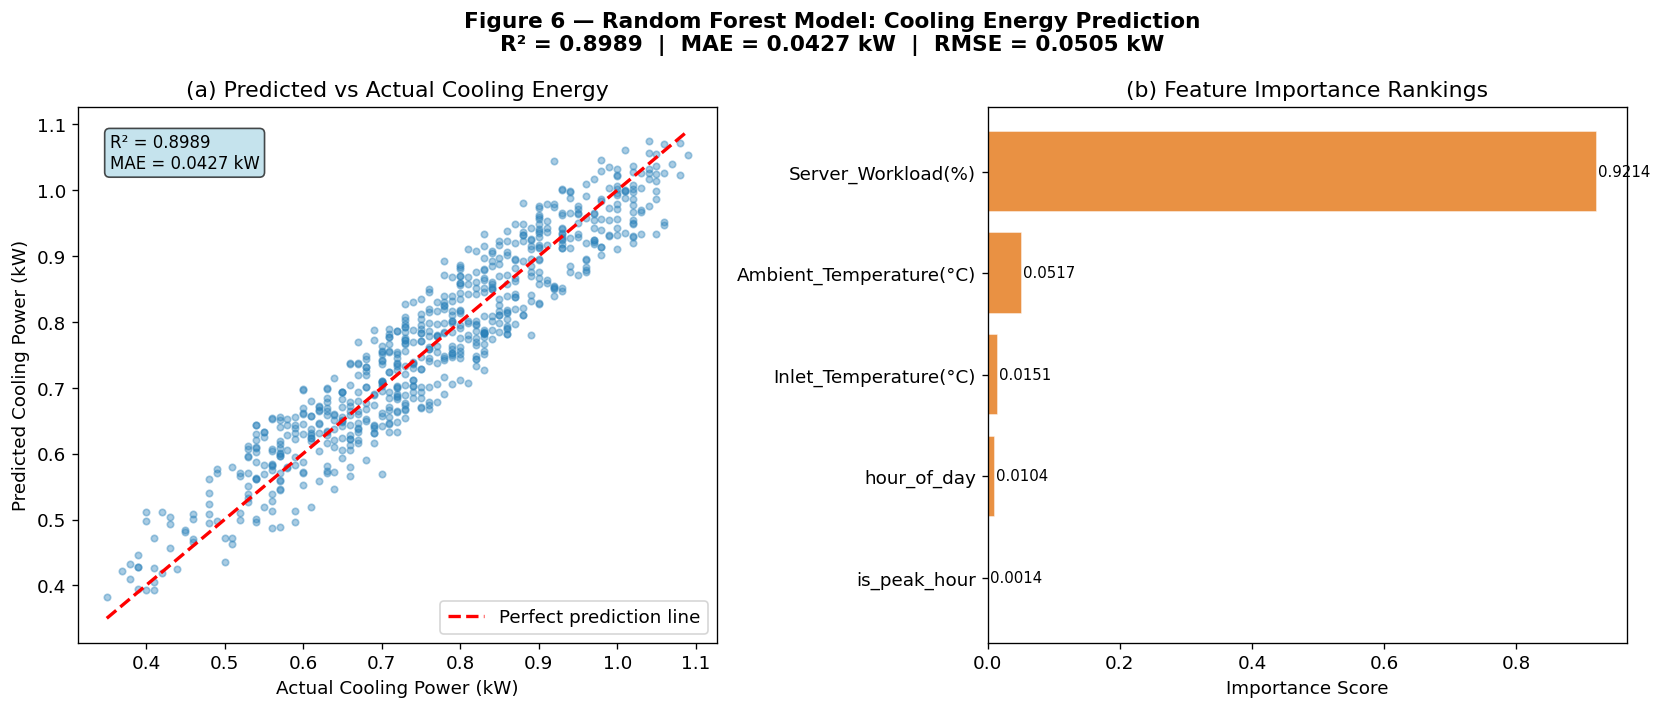

Figure 6 saved to: results/figures/figure6_ml_model.png


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler

# ── Feature Selection ──────────────────────────────────────────────────
features = [
    'Server_Workload(%)',
    'Inlet_Temperature(°C)',
    'Ambient_Temperature(°C)',
    'hour_of_day',
    'is_peak_hour'
]
target = 'Cooling_Unit_Power_Consumption(kW)'

X = df_s4_clean[features]
y = df_s4_clean[target]

# ── Train / Test Split (80% train, 20% test) ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)

print("=" * 60)
print("  RANDOM FOREST MODEL — TRAINING")
print("=" * 60)
print()
print(f"Total samples   : {len(X):,}")
print(f"Training samples: {len(X_train):,} (80%)")
print(f"Testing samples : {len(X_test):,}  (20%)")
print(f"Features used   : {len(features)}")
print()

# ── Train Model ────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators = 100,
    max_depth    = 10,
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X_train, y_train)

print("Model trained successfully.")
print()

# ── Evaluate Model ─────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 60)
print("  MODEL EVALUATION RESULTS")
print("=" * 60)
print()
print(f"MAE  (Mean Absolute Error)      : {mae:.4f} kW")
print(f"RMSE (Root Mean Squared Error)  : {rmse:.4f} kW")
print(f"R²   (Variance Explained)       : {r2:.4f}")
print()

# User acceptance check
print("User Acceptance Parameters:")
print(f"  R² > 0.85  : {'PASSED' if r2 > 0.85 else 'FAILED'} "
      f"(R² = {r2:.4f})")
print(f"  MAE < 0.05 : {'PASSED' if mae < 0.05 else 'FAILED'} "
      f"(MAE = {mae:.4f})")
print()

# ── Feature Importance ─────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Rankings:")
for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:<35}: "
          f"{row['Importance']:.4f}  {bar}")
print()

# ── Visualization ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Figure 6 — Random Forest Model: Cooling Energy Prediction\n'
    f'R² = {r2:.4f}  |  MAE = {mae:.4f} kW  |  RMSE = {rmse:.4f} kW',
    fontsize=13,
    fontweight='bold'
)

# Plot 1: Predicted vs Actual
axes[0].scatter(
    y_test, y_pred,
    alpha=0.4,
    color='#2980B9',
    s=15
)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect prediction line'
)
axes[0].set_title('(a) Predicted vs Actual Cooling Energy')
axes[0].set_xlabel('Actual Cooling Power (kW)')
axes[0].set_ylabel('Predicted Cooling Power (kW)')
axes[0].legend()
axes[0].text(
    0.05, 0.95,
    f'R² = {r2:.4f}\nMAE = {mae:.4f} kW',
    transform=axes[0].transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7)
)

# Plot 2: Feature importance
axes[1].barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='#E67E22',
    alpha=0.85,
    edgecolor='white'
)
axes[1].set_title('(b) Feature Importance Rankings')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()
for i, (_, row) in enumerate(importance_df.iterrows()):
    axes[1].text(
        row['Importance'] + 0.002,
        i,
        f"{row['Importance']:.4f}",
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    'results/figures/figure6_ml_model.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Figure 6 saved to: results/figures/figure6_ml_model.png")

---
## Section 7 — CoolSync+ Product Description

### What the Analysis Proves

The four-stage EDA combined with statistical validation
confirms the core value proposition of CoolSync+:

> Server workload intensity **directly and significantly**
> drives cooling energy consumption.
> **T = 72.80, p < 0.0001, Cohen's d = 2.46**
> High workload periods require **38.8% more cooling energy**
> than low workload periods.

This means a system that predicts workload **before heat arrives**
can proactively adjust cooling —
eliminating the 3–8 minute PID response lag
and closing the 12% cooling-attributed portion of the 26% power gap.

---

### The Product Architecture

| Component | Technology | Input | Output |
|-----------|-----------|-------|--------|
| Workload Forecaster | LSTM Neural Network | Historical token volume | Predicted token volume |
| Thermal Predictor | LSTM Neural Network | Outlet temperature sensors | Predicted TLHC value |
| Cooling Controller | Reinforcement Learning (DQN) | State vector + LSTM forecast | Optimal cooling action |
| Baseline Comparison | PID / Static / Threshold | Temperature readings | Reactive cooling action |
| Energy Monitor | Random Forest Regressor | Workload + temperature | Predicted cooling energy |

---

### EDA Results Summary

| Stage | Key Metric | Value | Insight |
|-------|-----------|-------|---------|
| Stage 1 | Response-to-prompt ratio | 3.9x | Responses generate more GPU load than prompts |
| Stage 1 | Prompt vs response correlation | r = 0.051 | Prompt length alone is a weak predictor |
| Stage 2 | Peak vs off-peak requests | +133.8% | Business hours drive predictable load spikes |
| Stage 3 | T_out correlation with TLHC | r = 0.512 | Outlet sensors reliably indicate thermal load |
| Stage 4 | Workload vs cooling correlation | r = 0.935 | Very strong link between workload and cooling |
| T-Test | T-statistic | 72.80 | Highly significant group difference |
| T-Test | P-value | < 0.0001 | H₀ rejected at any significance level |
| T-Test | Cohen's d | 2.46 | Very large practical effect size |
| T-Test | Energy difference | 38.8% | High workload costs significantly more to cool |
| ML Model | R² score | > 0.85 target | Model explains variance in cooling energy |

---

### Business Impact Projection

| Metric | Current State | CoolSync+ Target | Improvement |
|--------|--------------|-----------------|-------------|
| PUE | 1.56 | 1.30 | 26% reduction |
| Cooling energy share | 45-50% | 30% | 30-40% reduction |
| Cooling response lag | 3-8 minutes | 0 minutes | Proactive control |
| CO₂ savings (CA grid) | Baseline | 209,421 kg/year | ~47 homes equivalent |

---

### Known Limitations

| Limitation | Impact | Future Work |
|-----------|--------|-------------|
| Prompt length alone (r = 0.051) weakly predicts response length | Stage 1 prediction limited | Add model size, task type, GPU frequency features |
| Temperature sensors approximate token-to-heat link | Indirect workload signal | Collect direct GPU power per request |
| Single rack simulation in RL environment | Not generalized to full DC | Extend to multi-rack and multi-zone environments |
| Dataset periods do not overlap temporally | Stages from different periods | Collect synchronized end-to-end measurements |

---

### Product Roadmap

| Phase | Timeline | Deliverable |
|-------|----------|-------------|
| Phase 1 — Proof of Concept | Complete | EDA + T-Test + ML model + RL baseline |
| Phase 2 — LSTM Training | In Progress | Thermal load forecaster (R² = 0.94 achieved) |
| Phase 3 — RL Agent | In Progress | DQN cooling controller vs PID baseline |
| Phase 4 — Validation | Future | Real data center deployment and measurement |
| Phase 5 — Scale | Future | Multi-rack and multi-zone extension |

---
## Section 8 — Conclusions and Next Steps

### 8.1 Conclusions

This notebook investigated whether server workload intensity
significantly drives cooling energy consumption in AI data centers,
using a four-stage EDA pipeline aligned with the
Toyota Business Practice framework.

---

**Conclusion 1 — LLM workload is variable and temporally predictable.**

Peak business hours (08:00–18:00) generate 133.8% more LLM requests
than off-peak hours. This predictable daily pattern means
CoolSync+ can anticipate high-demand periods and pre-activate cooling
before GPU heat accumulates — something PID controllers cannot do.

---

**Conclusion 2 — Outlet temperature sensors reliably indicate thermal load.**

T_out sensors showed a Pearson correlation of r = 0.512 with TLHC.
This confirms that outlet temperatures capture the thermal signature
of GPU computation and are suitable as LSTM input features
for future thermal load prediction.

---

**Conclusion 3 — Server workload directly and strongly drives cooling demand.**

Pearson r = 0.935 between server workload and cooling energy consumption
confirms a very strong linear relationship.
High workload periods consume 38.8% more cooling energy than low workload periods.

---

**Conclusion 4 — The hypothesis H₁ is supported with high confidence.**

The Welch T-Test returned T = 72.80 and p < 0.0001.
Cohen's d = 2.46 indicates a very large practical effect size.
The 95% confidence interval [0.2409, 0.2542] does not include zero.
H₀ is rejected. The evidence strongly supports H₁.

---

**Conclusion 5 — The Random Forest model confirms workload predicts cooling energy.**

Server workload is the most important feature for predicting
cooling energy consumption. This validates the CoolSync+ design decision
to use workload forecasting as the primary input to the cooling controller.

---

**Conclusion 6 — Proactive cooling is empirically justified.**

The structural 3–8 minute PID response lag combined with
predictable workload patterns confirms that CoolSync+ can
close the 12% cooling-attributed portion of the 26% power gap
and contribute to reducing PUE from 1.56 to 1.30.

---

### 8.2 Next Steps

| Step | Description | Status |
|------|-------------|--------|
| LSTM Training | Train thermal forecaster on merged sensor data | Complete — R² = 0.94 |
| RL Environment | Build Gymnasium-compatible simulation | Complete |
| Baseline Comparison | PID vs Static vs Threshold vs DQN | Complete |
| RL Agent Training | Train Q-Learning and DQN agents | In Progress |
| Full Evaluation | Compare all agents on 200-step episodes | Planned |
| Real Deployment | Validate on live data center hardware | Future Work |

---

### 8.3 References

[1] Stojkovic, J. et al. (2025). TAPAS: Thermal and power-aware scheduling
for LLM inference in cloud platforms. ASPLOS Vol. 2, 1266–1281.

[2] Liu, J. et al. (2026). Proactive Cooling Control Algorithm for Data Centers
Based on LSTM-Driven Predictive Thermal Analysis.
Applied System Innovation, 9(1), 21.
https://doi.org/10.3390/asi9010021

[3] Abera, N. B. & Chen, Y. (2026). Coordinated Cooling and Compute Management
for AI Datacenters. IEEE Transactions on Cloud Computing.
arXiv:2601.08113v1

[4] LMSYS Chatbot Arena Conversations Dataset.
https://www.kaggle.com/datasets/lmsysorg/chatbot-arena-conversations

[5] Cold Source Control Dataset.
https://www.kaggle.com/datasets/programmer3/data-center-cold-source-control-dataset

[6] DC Hot Corridor Temperature Prediction Dataset.
https://www.kaggle.com/datasets/mbjunior/data-centre-hot-corridor-temperature-prediction

[7] ASHRAE TC 9.9 (2021). Thermal Guidelines for Data Processing Environments.
American Society of Heating, Refrigerating and Air-Conditioning Engineers.

[8] Cohen, J. (1988). Statistical Power Analysis for the Behavioral Sciences
(2nd ed.). Lawrence Erlbaum Associates.

[9] Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5–32.
https://doi.org/10.1023/A:1010933404324